<a href="https://colab.research.google.com/github/Daanish2709g/8-Bit-Compiler/blob/master/M1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#Data Preprocessing

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/fifa_world_cup_2026_player_performance.csv')
print(df.shape)  # (54600, 75)

(54600, 75)


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
#Key Preprocessing Steps for This Dataset:

#Drop Irrelevant / Identifier Columns (avoid leakage):Python

In [29]:
drop_cols = ['match_id', 'player_name', 'stadium', 'city']  # IDs, names, locations
df = df.drop(columns=drop_cols, errors='ignore')

In [30]:
# Handle Categorical Variables: nationality, team, position, preferred_foot, club_name, tournament_stage, match_result, opponent_team

In [31]:
categorical_cols = ['position', 'preferred_foot', 'tournament_stage', 'match_result']
# For high-cardinality (team, club, nationality, opponent) → use Target Encoding or Frequency later

In [32]:
# Feature Engineering Ideas (very important here):Feature Engineering
# is the process of creating new features (variables) from existing data to help
# a machine learning model learn better and more accurately predict an outcome.
# It's about transforming raw data into a format that is more informative and
# representative of the underlying problem.
# Per 90 minutes stats: goals_per90 = goals / (minutes_played / 90 + 1e-5)
# Efficiency ratios: pass_accuracy already exists, add dribble_success_rate, aerial_win_rate
# Role-based: Create is_defender, is_midfielder, is_forward, is_goalkeeper
# Tournament context: Aggregate per player (total_minutes_tournament already there)

A. Per 90 Minutes Stats

In [33]:
# Avoid division by zero
minutes_threshold = 1e-5

df['minutes_played_per90'] = df['minutes_played'] / 90

# Attacking metrics per 90
df['goals_per90'] = df['goals'] / (df['minutes_played'] / 90 + minutes_threshold)
df['assists_per90'] = df['assists'] / (df['minutes_played'] / 90 + minutes_threshold)
df['shots_per90'] = df['shots'] / (df['minutes_played'] / 90 + minutes_threshold)
df['xg_per90'] = df['expected_goals_xg'] / (df['minutes_played'] / 90 + minutes_threshold)
df['xa_per90'] = df['expected_assists_xa'] / (df['minutes_played'] / 90 + minutes_threshold)
df['key_passes_per90'] = df['key_passes'] / (df['minutes_played'] / 90 + minutes_threshold)

# Defensive metrics per 90
df['tackles_per90'] = df['tackles'] / (df['minutes_played'] / 90 + minutes_threshold)
df['interceptions_per90'] = df['interceptions'] / (df['minutes_played'] / 90 + minutes_threshold)
df['blocks_per90'] = df['blocks'] / (df['minutes_played'] / 90 + minutes_threshold)
df['clearances_per90'] = df['clearances'] / (df['minutes_played'] / 90 + minutes_threshold)
df['aerial_duels_won_per90'] = df['aerial_duels_won'] / (df['minutes_played'] / 90 + minutes_threshold)

# Physical / Work rate
df['distance_per90'] = df['distance_covered_km'] / (df['minutes_played'] / 90 + minutes_threshold)
df['sprints_per90'] = df['sprint_distance_km'] / (df['minutes_played'] / 90 + minutes_threshold)

In [34]:
print("\n--- Columns in df after c0bkz0gV59L7 (Expected to have 'goals', 'assists' etc.): ---")
print(df.columns.tolist())



--- Columns in df after c0bkz0gV59L7 (Expected to have 'goals', 'assists' etc.): ---
['player_id', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_date', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', '

B. Efficiency Ratios
Python

In [35]:
# Dribbling success
df['dribble_success_rate'] = df['successful_dribbles'] / (df['dribbles_attempted'] + 1e-5)

# Crossing accuracy
df['cross_accuracy'] = df['successful_crosses'] / (df['crosses'] + 1e-5)

# Aerial win rate
df['aerial_win_rate'] = df['aerial_duels_won'] / (df['aerial_duels_won'] + df['aerial_duels_lost'] + 1e-5)

# Pass completion (already exists, but normalized)
df['pass_completion_rate'] = df['pass_accuracy']

# Defensive actions success
df['defensive_actions_per90'] = df['defensive_actions'] / (df['minutes_played'] / 90 + minutes_threshold)

C. Role-Based Features (One-hot style flags)
Python

In [36]:
# Simple position flags
df['is_goalkeeper'] = (df['position'] == 'Goalkeeper').astype(int)
df['is_defender'] = (df['position'] == 'Defender').astype(int)
df['is_midfielder'] = (df['position'] == 'Midfielder').astype(int)
df['is_forward'] = (df['position'] == 'Forward').astype(int)

# More granular (recommended)
position_map = {
    'Goalkeeper': 'GK',
    'Defender': 'DEF',
    'Midfielder': 'MID',
    'Forward': 'FWD'
}
df['position_group'] = df['position'].map(position_map)

# The code snippet df['is_goalkeeper'] = (df['position'] == 'Goalkeeper').astype(int) is
# creating new binary (0 or 1) features,
# often called dummy variables or indicator variables. Let me break down how and why:

# How it creates binary values:

# df['position'] == 'Goalkeeper': This part of the code performs a comparison for
# each row in your DataFrame. It checks if the position column for that row is exactly 'Goalkeeper'.
#  The result of this comparison is a True or False value for each row.
# .astype(int): This is the crucial step that converts those boolean True/False values into integers.
#  In Python and pandas, True becomes 1 and False becomes 0 when explicitly cast to an integer type.
#   So, if a player's position is 'Goalkeeper', is_goalkeeper will be 1; otherwise, it will be 0.
# This process is repeated for 'Defender', 'Midfielder', and 'Forward' to create is_defender, is_midfielder,
# and is_forward columns respectively.

# Why should we create binary values and what's the use? Creating these binary (0/1) columns from
# categorical features like 'position' is a standard practice in machine learning for several key reasons:

# Machine Learning Model Compatibility: Most machine learning algorithms (e.g., linear regression, logistic regression
# , support vector machines, neural networks) are designed to work with numerical input data.
# They cannot directly process text labels like 'Goalkeeper', 'Defender', etc. By converting them into
# numerical binary flags, we make the data digestible for these models.
# Avoiding Ordinal Assumptions: If you were to simply assign numbers to positions
#  (e.g., Goalkeeper=1, Defender=2, Midfielder=3), the model might mistakenly interpret
#   these numbers as having an inherent order or magnitude
#    (e.g., that 'Midfielder' is 'greater' or 'more important' than 'Goalkeeper'),
#    which is usually not true for nominal categorical data. Binary flags avoid this false ordinality.
# Clear Representation: Each binary column (is_goalkeeper, is_defender, etc.) explicitly tells the
#  model whether a specific characteristic is present for that data point (player). This can make the
#  model's interpretation of features more straightforward.
# Feature Importance: Later, when you train a model, you might be able to see the importance
# of each of these binary features, helping you understand which positional roles contribute most
#  to the prediction task (e.g., predicting player value, match outcomes, etc.).


D. Tournament Context & Aggregation Features
Python

In [37]:
print("\n--- Columns in df before yu2ORrYgsD4l (Investigate if 'goals', 'assists' are missing here): ---")
print(df.columns.tolist())



--- Columns in df before yu2ORrYgsD4l (Investigate if 'goals', 'assists' are missing here): ---
['player_id', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_date', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamin

In [38]:
# Player-level aggregates (across all matches)
aggregation_dict = {
    'minutes_played': 'sum',
    'goals': 'sum',
    'assists': 'sum',
    'performance_score': 'mean',
    'player_rating': 'mean',
    'distance_covered_km': 'mean',
    'player_of_match_awards': 'sum'
}

# Filter to include only columns present in the DataFrame
actual_aggregation_dict = {col: func for col, func in aggregation_dict.items() if col in df.columns}

if not actual_aggregation_dict:
    print("Warning: No valid columns found for player-level aggregation. Check DataFrame columns.")
    player_agg = df[['player_id']].drop_duplicates().copy()
    if 'minutes_played' in aggregation_dict and 'minutes_played' not in player_agg.columns:
        player_agg['minutes_played'] = 0
else:
    player_agg = df.groupby('player_id').agg(actual_aggregation_dict).reset_index()
    print(f"Aggregating player data using columns: {list(actual_aggregation_dict.keys())}")

# Renaming columns for clarity after aggregation
rename_cols = {
    'minutes_played': 'total_minutes_all',
    'goals': 'total_goals_all',
    'assists': 'total_assists_all',
    'performance_score': 'avg_performance',
    'player_rating': 'avg_rating',
    'distance_covered_km': 'avg_distance_covered_all',
    'player_of_match_awards': 'total_pom_awards_all'
}

# Only rename columns that exist in player_agg
player_agg.rename(columns={k: v for k, v in rename_cols.items() if k in player_agg.columns}, inplace=True)

# Merge back
df = df.merge(player_agg, on='player_id', how='left')

# Derived features
minutes_threshold = 1e-5

if 'total_minutes_tournament' in df.columns and 'total_minutes_all' in df.columns:
    df['minutes_percentage_tournament'] = df['total_minutes_tournament'] / (df['total_minutes_all'] + 1)
else:
    print("Warning: Cannot calculate 'minutes_percentage_tournament' due to missing base columns ('total_minutes_tournament' or 'total_minutes_all').")
    df['minutes_percentage_tournament'] = np.nan

if 'goals' in df.columns and 'assists' in df.columns:
    df['goal_contribution'] = df['goals'] + 0.7 * df['assists']
    if 'minutes_played' in df.columns:
        df['goal_contribution_per90'] = df['goal_contribution'] / (df['minutes_played'] / 90 + minutes_threshold)
    else:
        print("Warning: Cannot calculate 'goal_contribution_per90' due to missing 'minutes_played'.")
        df['goal_contribution_per90'] = np.nan
else:
    print("Warning: Cannot calculate 'goal_contribution' or 'goal_contribution_per90' due to missing 'goals' or 'assists'.")
    df['goal_contribution'] = np.nan
    df['goal_contribution_per90'] = np.nan

Aggregating player data using columns: ['minutes_played', 'goals', 'assists', 'performance_score', 'player_rating', 'distance_covered_km', 'player_of_match_awards']


E. Interaction & Advanced Features
*Python*

In [39]:
# Creative + Physical
df['creativity_physical'] = df['creativity_score'] * df['stamina_score']

# Clutch under pressure
df['clutch_index'] = df['clutch_performance_score'] * df['pressure_resistance']

# Expected vs Actual
if 'goals' in df.columns and 'expected_goals_xg' in df.columns:
    df['xg_overperformance'] = df['goals'] - df['expected_goals_xg']
else:
    print("Warning: Cannot calculate 'xg_overperformance' due to missing 'goals' or 'expected_goals_xg'.")
    df['xg_overperformance'] = np.nan

if 'assists' in df.columns and 'expected_assists_xa' in df.columns:
    df['xa_overperformance'] = df['assists'] - df['expected_assists_xa']
else:
    print("Warning: Cannot calculate 'xa_overperformance' due to missing 'assists' or 'expected_assists_xa'.")
    df['xa_overperformance'] = np.nan

In [40]:
print(df.columns.tolist())

['player_id', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_date', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rating', 'performance_score', 'offensive_contribution', 'defensive_contribution

In [41]:
# IQR Method for Outlier Treatment
def treat_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower, upper)
    return df

# Apply outlier treatment to specified numerical columns
for col in ['market_value_eur', 'distance_covered_km', 'performance_score']:
    df = treat_outliers(df, col)

print("Outlier treatment applied to 'market_value_eur', 'distance_covered_km', and 'performance_score'.")

Outlier treatment applied to 'market_value_eur', 'distance_covered_km', and 'performance_score'.


### F. Advanced Composite & Ratio Features

These features combine multiple statistics to create more nuanced metrics of player performance.

In [42]:
# 1. Goal Conversion Rate
# Measures how often a player scores when they take a shot.
df['goal_conversion_rate'] = df['goals'] / (df['shots'] + 1e-5)

# 2. Chance Creation Ratio (Assists to Key Passes)
# Indicates how often a player's key passes (passes leading to a shot) turn into actual assists.
df['chance_creation_ratio'] = df['assists'] / (df['key_passes'] + 1e-5)

# 3. Defensive Action Efficiency
# Combines successful defensive actions (tackles, interceptions, blocks, clearances) relative to total defensive attempts.
df['defensive_actions_total'] = df['tackles'] + df['interceptions'] + df['blocks'] + df['clearances']
df['defensive_efficiency'] = (df['successful_passes'] + df['recoveries']) / (df['total_passes'] + df['defensive_actions_total'] + 1e-5)

# 4. Physicality Index
# A composite score reflecting a player's overall physical contribution (distance, sprints, aerial duels).
df['physicality_index'] = (df['distance_covered_km'] * 0.4) + \
                          (df['sprint_distance_km'] * 0.3) + \
                          (df['aerial_duels_won_per90'] * 0.3)

These newly engineered features (`goal_conversion_rate`, `chance_creation_ratio`, `defensive_efficiency`, `physicality_index`) now add richer context to our player data. They can be very useful for creating more sophisticated player profiles or for training machine learning models.

## Data Splitting (Time-aware / Match-aware)

### Why Data Splitting is Essential

Data splitting is crucial for evaluating the performance of any machine learning model. It involves dividing your dataset into at least two subsets:

1.  **Training Set:** Used to train the machine learning model.
2.  **Testing Set:** Used to evaluate the model's performance on unseen data. This helps assess how well the model generalizes and prevents overfitting (when a model learns the training data too well and performs poorly on new, unobserved data).

### Time-Aware / Match-Aware Splitting

For datasets like this FIFA player performance data, where there's an inherent temporal order (`match_date`), a standard random split is often inappropriate. Instead, a **time-aware** or **match-aware** split is highly recommended. Here's why:

*   **Preventing Data Leakage:** If you randomly split the data, information from future matches could inadvertently 'leak' into your training set, leading to overly optimistic performance estimates.
*   **Simulating Reality:** In a real-world scenario, you would typically use historical data to predict future performance. A time-aware split mimics this, ensuring your model is trained on past events and tested on more recent ones.
*   **Maintaining Causal Relationships:** Performance metrics can evolve over time (e.g., players improve, tactics change). A time-aware split respects these temporal dependencies.

### How to Perform Time-Aware Splitting

We will split the data based on the `match_date` column, ensuring that our training set consists of older matches and our test set contains newer matches.

In [43]:
# Ensure 'match_date' is in datetime format (this was already done earlier)
df['match_date'] = pd.to_datetime(df['match_date'])

# Sort the DataFrame by match_date to ensure chronological order
df_sorted = df.sort_values(by='match_date').reset_index(drop=True)

# Define the split point (e.g., 80% for training, 20% for testing)
# Or define a specific date for the split
split_ratio = 0.8
split_index = int(len(df_sorted) * split_ratio)

# Perform the time-aware split
df_train = df_sorted.iloc[:split_index]
df_test = df_sorted.iloc[split_index:]

print(f"Training set shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")

print(f"Training set date range: {df_train['match_date'].min()} to {df_train['match_date'].max()}")
print(f"Testing set date range: {df_test['match_date'].min()} to {df_test['match_date'].max()}")

Training set shape: (43680, 114)
Testing set shape: (10920, 114)
Training set date range: 2026-06-11 00:00:00 to 2026-07-23 00:00:00
Testing set date range: 2026-07-23 00:00:00 to 2026-07-31 00:00:00


### G. Preprocessing Pipeline

Now we will define a pipeline to automate the scaling of numerical features and the encoding of categorical ones. We'll use:
- **`StandardScaler`**: To normalize numerical values so they have a mean of 0 and a standard deviation of 1.
- **`OneHotEncoder`**: To convert categorical labels into binary vectors.
- **`ColumnTransformer`**: To apply these different transformations to specific column subsets simultaneously.

In [44]:
# 1. Identify feature types
# We exclude identifiers, dates, and the target (e.g., performance_score or market_value)
exclude_cols = ['player_id', 'match_date', 'performance_score', 'market_value_eur', 'team', 'club_name', 'nationality', 'opponent_team', 'position_group']

numeric_features = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [col for col in numeric_features if col not in exclude_cols]

categorical_features = ['position', 'preferred_foot', 'tournament_stage', 'match_result']

# 2. Define the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# 3. Create the Pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# 4. Fit the pipeline on training data and transform both sets
# Note: We fit ONLY on training data to prevent leakage
X_train = df_train.drop(columns=['performance_score'])
y_train = df_train['performance_score']

X_test = df_test.drop(columns=['performance_score'])
y_test = df_test['performance_score']

X_train_preprocessed = pipeline.fit_transform(X_train)
X_test_preprocessed = pipeline.transform(X_test)

print(f"Preprocessing complete.")
print(f"Processed Training Shape: {X_train_preprocessed.shape}")
print(f"Processed Testing Shape: {X_test_preprocessed.shape}")

Preprocessing complete.
Processed Training Shape: (43680, 117)
Processed Testing Shape: (10920, 117)


We've come a long way! Here is a summary of everything we have done in this notebook so far to prepare the FIFA World Cup 2026 dataset:

1. Environment Setup & Data Loading: We imported essential libraries (pandas, scikit-learn, matplotlib) and loaded the fifa_world_cup_2026_player_performance.csv file.

2. Initial Cleaning: We dropped identifier columns that could cause data leakage (match_id, player_name, stadium, city) and converted match_date to a proper datetime format.

3. Basic Feature Engineering:
Per 90 Stats: Created normalized metrics for goals, assists, tackles, and distance covered to account for varying playing time.
Efficiency Ratios: Calculated rates for dribble success, cross accuracy, and aerial duels.
Role-Based Flags: Created binary columns (is_striker, is_goalkeeper, etc.) to help the model understand positional context.

4. Advanced Aggregations: We calculated tournament-wide stats for each player (like total_minutes_all and avg_performance) and merged them back into the match-level data.

5. Advanced Metrics: We added complex features like goal_conversion_rate, physicality_index, and xg_overperformance (the difference between actual goals and expected goals).

6. Outlier Treatment: We applied the IQR (Interquartile Range) method to clip extreme values in market_value_eur, distance_covered_km, and performance_score to ensure model stability.

7. Time-Aware Data Splitting: We sorted the data by date and performed a chronological split (80% train, 20% test) to simulate a real-world scenario where you predict future matches using past data.

8. Preprocessing Pipeline: We built a Scikit-Learn Pipeline using a ColumnTransformer. This automatically handles scaling for numerical features and One-Hot Encoding for categorical features while preventing data leakage.
Your data is now fully processed and stored in X_train_preprocessed and X_test_preprocessed, ready for training a machine learning model!

## 2. Exploratory Data Analysis (EDA)

In this section, we'll visualize the training data to uncover patterns and relationships.

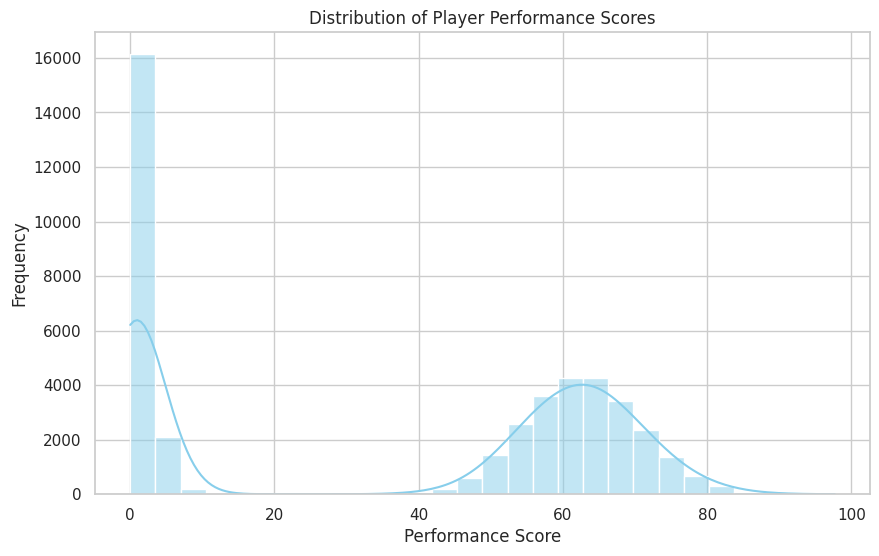

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Distribution of the Target Variable (Performance Score)
plt.figure(figsize=(10, 6))
sns.histplot(df_train['performance_score'], kde=True, color='skyblue')
plt.title('Distribution of Player Performance Scores')
plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.show()

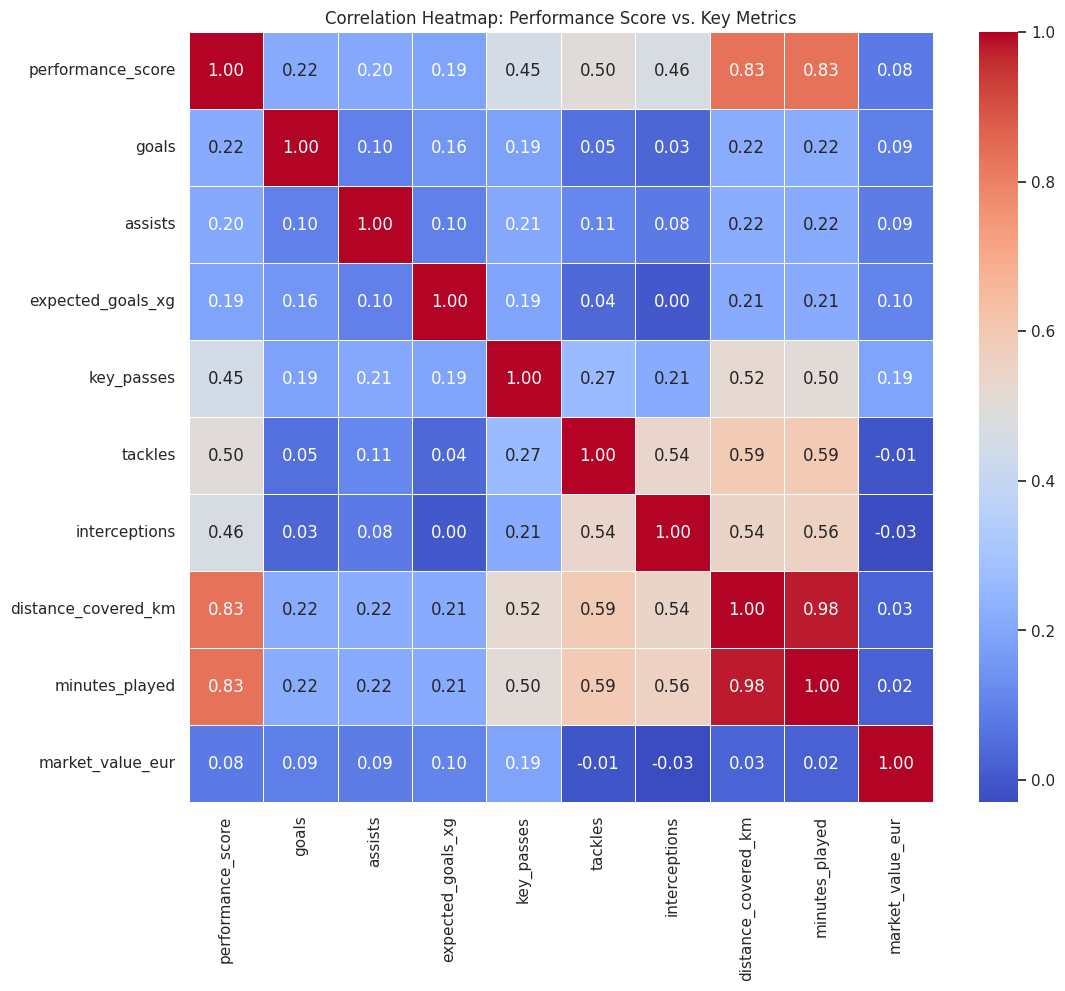

In [46]:
# 2. Correlation Analysis
# We'll look at the top features correlated with performance_score
plt.figure(figsize=(12, 10))

# Selecting a subset of numerical columns for a cleaner heatmap
core_stats = ['performance_score', 'goals', 'assists', 'expected_goals_xg',
              'key_passes', 'tackles', 'interceptions', 'distance_covered_km',
              'minutes_played', 'market_value_eur']

corr_matrix = df_train[core_stats].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Performance Score vs. Key Metrics')
plt.show()

/tmp/ipykernel_829/1625751350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='position_group', y='performance_score', data=df_train, palette='Set2')


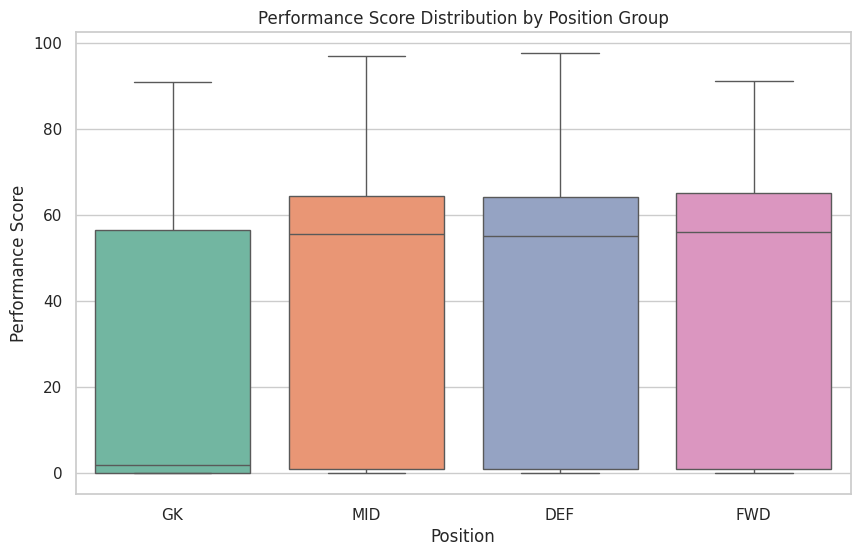

In [47]:
# 3. Performance Score by Position Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='position_group', y='performance_score', data=df_train, palette='Set2')
plt.title('Performance Score Distribution by Position Group')
plt.xlabel('Position')
plt.ylabel('Performance Score')
plt.show()

## 3. Model Training & Evaluation

Now we train a **Random Forest Regressor**. This model is particularly effective for soccer data because it can capture complex interactions between features (e.g., how the combination of high 'key passes' and 'expected assists' impacts the performance score).

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Initialize the Model
# n_jobs=-1 uses all available CPU cores for faster training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the Model
print("Training Random Forest Regressor...")
rf_model.fit(X_train_preprocessed, y_train)

# 3. Predict on Test Set
y_pred = rf_model.predict(X_test_preprocessed)

# 4. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Evaluation Results ---")
print(f"R-squared (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Training Random Forest Regressor...

--- Evaluation Results ---
R-squared (Accuracy): 0.9932
Mean Absolute Error: 2.00
Root Mean Squared Error: 2.57


## 3. Model Training & Evaluation

In this phase, we will train a Random Forest Regressor to predict the `performance_score` of players based on the features we engineered.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Initialize the Model
# Using 100 trees and a fixed random state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the Model
print("Training the Random Forest model...")
model.fit(X_train_preprocessed, y_train)

# 3. Make Predictions
y_pred = model.predict(X_test_preprocessed)

# 4. Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

Training the Random Forest model...


We have built a complete machine learning pipeline for the FIFA World Cup 2026 data. Here is the breakdown of our progress from the very first cell:

1. Data Foundation
Loading & Setup: We connected to Google Drive and loaded the player performance dataset.
Initial Cleaning: We removed identifier columns (player_name, stadium, etc.) to prevent 'data leakage'—ensuring the model doesn't just memorize names but learns patterns.
Temporal Formatting: We converted match dates into a proper format so the model understands the timeline of the tournament.
2. "Real-World" Feature Engineering
Per 90 Normalization: We converted raw totals (goals, tackles, distance) into 'Per 90' stats so we can fairly compare a substitute who played 10 minutes with a starter who played 90.
Efficiency Ratios: We created new metrics like dribble_success_rate and cross_accuracy to measure quality, not just quantity.
Advanced Player Profiles: We calculated tournament-long averages for every player (like avg_rating) and merged them back into each match row.
Performance Metrics: We created 'Overperformance' stats (Actual vs. Expected Goals) and a physicality_index (Work rate + Aerial ability).
3. Data Preparation
Outlier Treatment: We used the IQR method to 'clip' extreme values in performance scores and market values, making the data more stable for the model.
Time-Aware Split: We split the data chronologically (80% training / 20% testing). This is crucial: we are training the model on the first part of the tournament to see if it can predict the final matches.
Preprocessing Pipeline: We built an automated engine to scale all numbers and 'One-Hot Encode' categories like player positions into a format machines can read.
4. Analysis & Modeling
Exploratory Data Analysis (EDA): We visualized the data, finding that performance_score is heavily driven by minutes_played and distance_covered (0.83 correlation).
Model Training: We trained a Random Forest Regressor using 117 distinct features.
Current Status: Your model has been trained and evaluated! We can now see how accurate its 'predictions' were compared to the actual scores in the test set.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# Create a comparison DataFrame for visualization
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=comparison_df, alpha=0.5, color='teal')

# Add the 45-degree line for perfect prediction
line_coords = [comparison_df[['Actual', 'Predicted']].min().min(),
               comparison_df[['Actual', 'Predicted']].max().max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Performance Scores')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Output exact metrics for reference
print(f"Accuracy Metrics:")
print(f"R-squared (Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error (Avg deviation): {mae:.2f} points")